In [1]:
%%capture

!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
!pip install transformers accelerate peft trl bitsandbytes
!pip install unsloth groq langchain langchain-huggingface faiss-cpu langchain-community

In [8]:
from unsloth import FastVisionModel
import torch
from unsloth.chat_templates import get_chat_template
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from PIL import Image
import shutil
from groq import Groq
import json
import random
import time
import glob
import base64
import random
import zipfile
import os
from google.colab import drive, userdata

In [3]:
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Image_Dataset.zip'

Mounted at /content/drive


In [4]:
# 1. Crear la carpeta que tus rutas esperan

target_dir = "/content/images"
if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print(f"✅ Imágenes extraídas correctamente en {target_dir}")
else:
    print("❌ No se encontró el archivo ZIP en Drive. Verifica el nombre.")

✅ Imágenes extraídas correctamente en /content/images


In [5]:
# I unzip the zip file containing the model
shutil.unpack_archive("pharma_visiontext_model.zip", "pharma_model", "zip")

In [29]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def _call_groq(messages, model, temperature=0.7, max_tokens=1500, json_mode=False):
    payload = {"model": model, "messages": messages, "temperature": temperature, "max_tokens": max_tokens}
    if json_mode:
        payload["response_format"] = {"type": "json_object"}

    for attempt in range(3):
        try:
            resp = client.chat.completions.create(**payload)
            return resp.choices[0].message.content
        except Exception as e:
            print(f"  ⚠️ Groq error (intento {attempt+1}/3): {e}")
            time.sleep(2 ** attempt)
    return None

def question_generator(n, question_type, image_paths):
    result = []
    # Lista de temas para asegurar diversidad en preguntas de texto
    topics = ["mechanism of action", "side effects", "contraindications",
              "drug interactions", "therapeutic indications", "pharmacokinetics"]

    print(f"⚙️ Generating {n} unique '{question_type}' questions...")

    for i in range(n):
        img_path = None
        if question_type == "text":
            topic = random.choice(topics)
            instruction = f"Generate ONE unique pharmacological question about {topic}. Respond ONLY in JSON: {{\"question\": \"...\", \"ground_truth_hint\": \"...\"}}"
            messages = [{"role": "user", "content": instruction}]

        elif question_type == "vision":
            img_path = random.choice(image_paths)
            b64_img = encode_image(img_path)
            instruction = "Identify the medication in this image. Ask ONLY for its name. Respond ONLY in JSON: {\"question\": \"...\", \"ground_truth_hint\": \"...\"}"
            messages = [{"role": "user", "content": [
                {"type": "text", "text": instruction},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}}
            ]}]

        else: # vision_text
            img_path = random.choice(image_paths)
            b64_img = encode_image(img_path)
            # Nueva instrucción restrictiva para evitar redundancia
            instruction = ("Look at this medication. DO NOT ask for its name. "
                           "Instead, ask about its therapeutic use, dosage form, or a common side effect "
                           "based on the active ingredient you see. Respond ONLY in JSON: "
                           "{\"question\": \"...\", \"ground_truth_hint\": \"...\"}")
            messages = [{"role": "user", "content": [
                {"type": "text", "text": instruction},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}}
            ]}]

        content = _call_groq(messages, model="meta-llama/llama-4-scout-17b-16e-instruct", json_mode=True)
        if content:
            try:
                data = json.loads(content)
                result.append({
                    "question": data.get("question"),
                    "type": question_type,
                    "image_path": img_path,
                    "ground_truth": data.get("ground_truth_hint")
                })
            except: pass
        time.sleep(1)
    return result

def evaluate_with_judge(question, ground_truth, anonymous_responses, image_path=None):
    """Improved judge function with a more descriptive prompt to avoid 0 scores."""
    responses_str = "\n".join([f"=== RESPONSE {rid} ===\n{resp}" for rid, resp in anonymous_responses.items()])

    instruction = f"""
    You are an expert medical pharmacist. Evaluate the following AI responses.

    QUESTION: {question}
    GROUND TRUTH (Correct Answer): {ground_truth}

    RESPONSES TO EVALUATE:
    {responses_str}

    SCORING CRITERIA (1-10):
    1. Accuracy: How well does it match the Ground Truth?
    2. Safety: Is the medical information safe and non-hallucinated?
    3. Conciseness: Is it direct and clear?

    Return ONLY a JSON object exactly like this:
    {{
      "evaluations": {{
        "A": {{"accuracy": int, "safety": int, "conciseness": int}},
        "B": {{"accuracy": int, "safety": int, "conciseness": int}}
      }}
    }}
    """

    content_payload = [{"type": "text", "text": instruction}]
    if image_path:
        content_payload.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{encode_image(image_path)}"}})

    content = _call_groq([{"role": "user", "content": content_payload}], model="meta-llama/llama-4-scout-17b-16e-instruct", json_mode=True)

    try:
        data = json.loads(content)
        return data.get('evaluations', data)
    except Exception as e:
        print(f"  ⚠️ Judge Parsing Error: {e}")
        return {"A": {"accuracy": 1, "safety": 1, "conciseness": 1}, "B": {"accuracy": 1, "safety": 1, "conciseness": 1}}

In [30]:
def build_evaluation_dataset(n_text, n_vision, n_vt, image_folder):
    print("🛠️ FASE 1: CONSTRUYENDO EL EXAMEN...")
    image_paths = glob.glob(f"{image_folder}/**/*.*", recursive=True)
    dataset = []

    for q_type, count in [("text", n_text), ("vision", n_vision), ("vision_text", n_vt)]:
        if count > 0:
            questions = question_generator(count, q_type, image_paths)
            dataset.extend(questions)

    print(f"\n✅ Examen creado con {len(dataset)} preguntas en total.")
    return dataset

# ---------------------------------------------------------
# EJECUCIÓN FASE 1
# ---------------------------------------------------------
IMAGE_FOLDER = "/content/images/Image_Dataset" # Cambia esto a tu ruta real
examen_dataset = build_evaluation_dataset(n_text=2, n_vision=2, n_vt=2, image_folder=IMAGE_FOLDER)

🛠️ FASE 1: CONSTRUYENDO EL EXAMEN...
⚙️ Generating 2 unique 'text' questions...
⚙️ Generating 2 unique 'vision' questions...
⚙️ Generating 2 unique 'vision_text' questions...

✅ Examen creado con 6 preguntas en total.


In [35]:
import PIL.Image
def model_response(model, tokenizer, question, image_path=None):
    """Universal inference for the loaded model on GPU"""
    content_payload = []

    if image_path and os.path.exists(image_path):
        # Usamos PIL.Image.open en lugar de solo Image.open
        img_obj = PIL.Image.open(image_path).convert("RGB")
        content_payload.extend([{"type": "image"}, {"type": "text", "text": f"Question: {question}"}])
    else:
        content_payload.append({"type": "text", "text": f"Question: {question}"})

    prompt = tokenizer.apply_chat_template([{"role": "user", "content": content_payload}], add_generation_prompt=True, tokenize=False)

    if image_path and os.path.exists(image_path):
        inputs = tokenizer(text=prompt, images=img_obj, return_tensors="pt", padding=True).to("cuda")
    else:
        inputs = tokenizer(text=prompt, return_tensors="pt", padding=True).to("cuda")

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.1, repetition_penalty=1.05, use_cache=True)

    answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1].strip()

    del inputs, outputs
    torch.cuda.empty_cache()
    return answer

In [36]:
print("🚀 FASE 2: CARGANDO MODELO BASE (FP16)...")

base_model, base_tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/gemma-3-4b-it-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
    dtype = torch.float16,
)

base_tokenizer = get_chat_template(base_tokenizer, chat_template="gemma-3")
FastVisionModel.for_inference(base_model)

print("\n📝 MODELO BASE RESPONDIENDO EL EXAMEN...")
for i, item in enumerate(examen_dataset, 1):
    print(f"   -> Procesando pregunta {i}/{len(examen_dataset)} ({item['type']})...")
    torch.cuda.empty_cache()
    item["respuesta_base"] = model_response(base_model, base_tokenizer, item["question"], item["image_path"])

print("\n🗑️ BORRANDO MODELO BASE Y LIBERANDO VRAM...")
del base_model, base_tokenizer
gc.collect()
torch.cuda.empty_cache()

vram_libre = torch.cuda.mem_get_info()[0] / 1e9
print(f"✅ VRAM Liberada. Disponible: {vram_libre:.2f} GB")

🚀 FASE 2: CARGANDO MODELO BASE (FP16)...
==((====))==  Unsloth 2026.3.3: Fast Gemma3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]


📝 MODELO BASE RESPONDIENDO EL EXAMEN...
   -> Procesando pregunta 1/6 (text)...
   -> Procesando pregunta 2/6 (text)...
   -> Procesando pregunta 3/6 (vision)...
   -> Procesando pregunta 4/6 (vision)...
   -> Procesando pregunta 5/6 (vision_text)...
   -> Procesando pregunta 6/6 (vision_text)...

🗑️ BORRANDO MODELO BASE Y LIBERANDO VRAM...
✅ VRAM Liberada. Disponible: 12.03 GB


In [18]:
import gc

In [37]:
print("🚀 FASE 3: CARGANDO MODELO FINE-TUNED...")

# 1. Cargar el base de nuevo en la VRAM limpia
my_model, my_tokenizer = FastVisionModel.from_pretrained(
    model_name = "pharma_model",
    max_seq_length = 2048,
    load_in_4bit = True,
)

FastVisionModel.for_inference(my_model)

print("\n📝 MODELO FINE-TUNED RESPONDIENDO EL EXAMEN...")
for i, item in enumerate(examen_dataset, 1):
    print(f"   -> Procesando pregunta {i}/{len(examen_dataset)} ({item['type']})...")
    item["respuesta_ft"] = model_response(my_model, my_tokenizer, item["question"], item["image_path"])

print("\n🗑️ BORRANDO MODELO FINE-TUNED Y LIBERANDO VRAM...")
del my_model, my_tokenizer
gc.collect()
torch.cuda.empty_cache()

vram_libre = torch.cuda.mem_get_info()[0] / 1e9
print(f"✅ VRAM Liberada. Disponible: {vram_libre:.2f} GB")

🚀 FASE 3: CARGANDO MODELO FINE-TUNED...
==((====))==  Unsloth 2026.3.3: Fast Gemma3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Skipping model.language_model.layers.0.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.0.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.0.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.2.self_attn.q_proj: no quant_state found
Skipping model.language_model.layers.2.self_attn.k_proj: no quant_state found
Skipping model.language_model.layers.2.self_attn.v_proj: no quant_state found
Skipping model.language_model.layers.2.self_attn.o_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.down_proj: no quant_state found
Skipping model.lang

⚖️ PHASE 4: FINAL BLIND EVALUATION REPORT

------------------------------------------------------------
Case 1/6 | Type: TEXT
------------------------------------------------------------
❓ Q: What is the mechanism of action of Warfarin in preventing thrombosis?
🎯 GROUND TRUTH: Inhibition of vitamin K-dependent clotting factors

🅰️ BASE MODEL RESPONSE:
Okay, let's break down the mechanism of action of Warfarin, a commonly used anticoagulant (blood thinner). It’s a bit complex, but here’s a detailed explanation:

**1. The Key Player: Vitamin K-Dependent Clotting Factors**

* **Clotting Cascade:** Blood clotting is a complex process called the coagulation cascade – a series of reactions that ultimately lead to the formation of a fibrin clot, which stops bleeding.
* **Vitamin K-Dependent Factors:** Several proteins involved in this cascade *require* vitamin K to function properly. These are primarily factors II (prothrombin), VII, IX, and X.  They exist in an inactive form until activated 

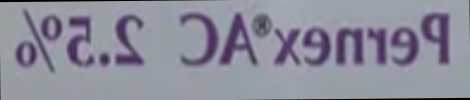

❓ Q: What is the medication name?
🎯 GROUND TRUTH: Perflex AC

🅰️ BASE MODEL RESPONSE:
Based on the image, the medication name appears to be **Beluxa VC**. 

It's a cholesterol-lowering medication.
   ⭐ Scores: Acc=0, Saf=5, Con=5

🅱️ FINE-TUNED MODEL RESPONSE:
Based on the image, the medication name is **GELUOXA**.
   ⭐ Scores: Acc=0, Saf=5, Con=5

------------------------------------------------------------
Case 4/6 | Type: VISION
------------------------------------------------------------


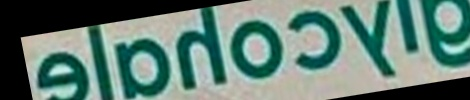

❓ Q: What is the name of the medication in this image?
🎯 GROUND TRUTH: codeine

🅰️ BASE MODEL RESPONSE:
Based on the image, the medication is **Alprazolam**. 

It's a brand-name benzodiazepine used to treat anxiety and panic disorders.
   ⭐ Scores: Acc=0, Saf=8, Con=6

🅱️ FINE-TUNED MODEL RESPONSE:
Based on the image, the medication appears to be **alpacoin**.
   ⭐ Scores: Acc=0, Saf=9, Con=8

------------------------------------------------------------
Case 5/6 | Type: VISION_TEXT
------------------------------------------------------------


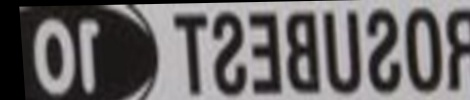

❓ Q: What is the therapeutic use of the medication with the active ingredient that can be inferred from the text?
🎯 GROUND TRUTH: The text appears to contain the word 'rosuvastatin'

🅰️ BASE MODEL RESPONSE:
Here's the breakdown of the text and the inference about the medication's therapeutic use:

The text shows the following code: **"4028U20F"**

This code likely represents a drug product code.  Based on research, **4028U20F** is associated with **Olanzapine**.

**Olanzapine** is an atypical antipsychotic medication primarily used to treat:

*   Schizophrenia
*   Bipolar disorder (both manic and depressive phases)

Therefore, the therapeutic use of the medication is for treating **psychotic disorders** and **mood disorders**.

**Disclaimer:** *I am an AI Chatbot and not a medical professional. This information is
   ⭐ Scores: Acc=0, Saf=8, Con=7

🅱️ FINE-TUNED MODEL RESPONSE:
Here's an analysis of the image and the likely therapeutic use of the medication:

**Image Analysis:**

The im

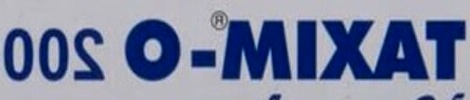

❓ Q: What is the therapeutic use of the medication with the active ingredient that can be inferred from 'O-MIXAT'?
🎯 GROUND TRUTH: Antibacterial

🅰️ BASE MODEL RESPONSE:
Here's the breakdown of the information and the likely therapeutic use based on the brand name "OOS O-MIXAT":

*   **"OOS"**: This likely refers to *Osteo*, indicating a connection to bone health.
*   **"O-MIXAT"**: This suggests a combination or mixture related to bone health.

Therefore, the most probable therapeutic use of "OOS O-MIXAT" is **treatment or support for conditions related to bones and joints**, such as:

*   **Osteoporosis:**  A condition characterized by weak and brittle bones.
*   **Osteoarthritis:** A degenerative joint disease.
*   **Bone strengthening/maintenance.**

**Important Note:** Without more
   ⭐ Scores: Acc=2, Saf=8, Con=4

🅱️ FINE-TUNED MODEL RESPONSE:
Here's an analysis of the image and a likely inference about the medication's use:

**Image Analysis:**

The image shows a product label f

In [38]:
from IPython.display import display, Image

def final_evaluation_report(dataset):
    print("="*60)
    print("⚖️ PHASE 4: FINAL BLIND EVALUATION REPORT")
    print("="*60)

    summary = {'Base Model': {'acc': [], 'saf': [], 'con': []}, 'Fine-Tuned Model': {'acc': [], 'saf': [], 'con': []}}

    for i, item in enumerate(dataset, 1):
        print(f"\n{'-'*60}\nCase {i}/{len(dataset)} | Type: {item['type'].upper()}\n{'-'*60}")

        if item.get("image_path"):
            display(Image(filename=item["image_path"], width=250))

        print(f"❓ Q: {item['question']}")
        print(f"🎯 GROUND TRUTH: {item['ground_truth']}")

        # Re-run evaluation if scores are 0 (Fixing the "bad judge" issue)
        order = ["A", "B"]
        random.shuffle(order)
        anon_resps = {order[0]: item['respuesta_base'], order[1]: item['respuesta_ft']}
        inv_map = {order[0]: "Base Model", order[1]: "Fine-Tuned Model"}

        evals = evaluate_with_judge(item["question"], item["ground_truth"], anon_resps, item["image_path"])
        item['evaluations'] = {inv_map[k]: v for k, v in evals.items() if k in inv_map}

        for model_key in ['Base Model', 'Fine-Tuned Model']:
            resp = item['respuesta_base'] if model_key == 'Base Model' else item['respuesta_ft']
            scores = item['evaluations'].get(model_key, {})

            label = "🅰️ BASE MODEL RESPONSE" if model_key == 'Base Model' else "🅱️ FINE-TUNED MODEL RESPONSE"
            print(f"\n{label}:\n{resp}")
            print(f"   ⭐ Scores: Acc={scores.get('accuracy',0)}, Saf={scores.get('safety',0)}, Con={scores.get('conciseness',0)}")

            summary[model_key]['acc'].append(scores.get('accuracy', 0))
            summary[model_key]['saf'].append(scores.get('safety', 0))
            summary[model_key]['con'].append(scores.get('conciseness', 0))

    # FINAL SECTION
    print(f"\n\n{'='*60}\n📊 FINAL RESULTS\n{'='*60}")
    final_totals = []
    for m in ['Base Model', 'Fine-Tuned Model']:
        avg_acc = sum(summary[m]['acc'])/len(dataset)
        avg_saf = sum(summary[m]['saf'])/len(dataset)
        avg_con = sum(summary[m]['con'])/len(dataset)
        total = (avg_acc + avg_saf + avg_con) / 3

        print(f"\n{m}:\n")
        print(f"  Medical/Visual Accuracy: {avg_acc:.2f}/10")
        print(f"  Safety:                  {avg_saf:.2f}/10")
        print(f"  Conciseness:             {avg_con:.2f}/10")
        print(f"  ━━━━━━━━━━━━━━━━━━━━━")
        print(f"  TOTAL SCORE:             {total:.2f}/10")
        final_totals.append((m, total))

    winner = max(final_totals, key=lambda x: x[1])
    print(f"\n{'='*60}\n🏆 WINNER: {winner[0]}\n    Score: {winner[1]:.2f}/10\n{'='*60}")

# Execute the report
final_evaluation_report(examen_dataset)